In [1]:
!pip install --upgrade bitsandbytes

In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

print("Hello")

Tue Jan 20 13:52:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             53W /  400W |   21669MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


FFHQ dataset loaded successfully.


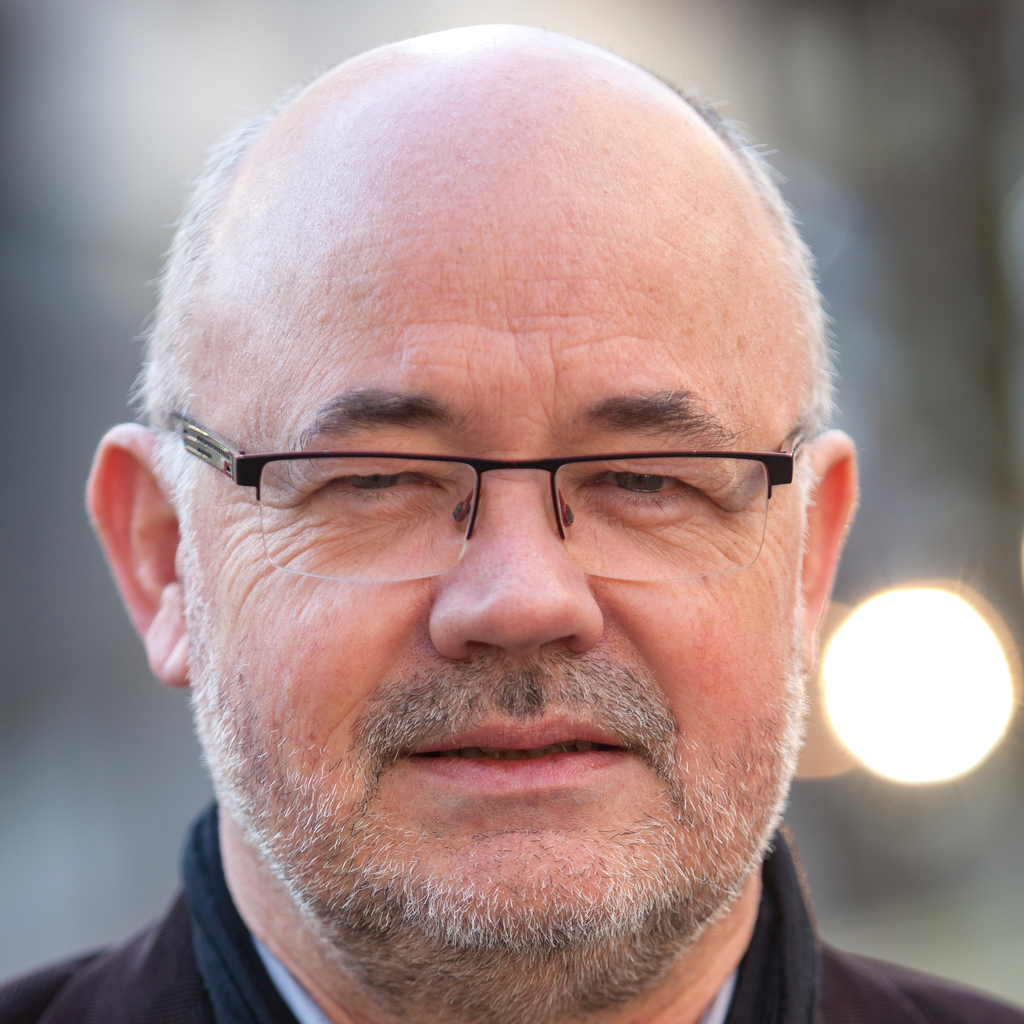

In [4]:
from datasets import load_dataset

dataset = load_dataset('Iceclear/FFHQ-HQ1024')
print("FFHQ dataset loaded successfully.")

im = dataset['train'][256]
im['image']

In [5]:
# prompt = "a photo of a cat"
# image = pipe(prompt).images[0]  
    
# image.save("Test_SB_Image.png")

image = im['image']

In [6]:
from diffusers import AutoencoderKL
import torch

# vae = AutoencoderKL.from_pretrained(
#     "runwayml/stable-diffusion-v1-5",
#     subfolder="vae",
#     torch_dtype=torch.float32
# ).to("cuda")

vae = pipe.vae

In [7]:
import numpy as np

img = np.array(image).astype(np.float32) / 255.0
img = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to("cuda", dtype=torch.float16)
img = img * 2.0 - 1.0  # [-1,1]

# Print Original Image Shape
print(f'Original Image Shape is: {img.shape}')

Original Image Shape is: torch.Size([1, 3, 1024, 1024])


In [8]:
with torch.no_grad():
    latent = vae.encode(img).latent_dist.sample() * 0.18215

print(f"Latent shape: {latent.shape}, dtype: {latent.dtype}")

Latent shape: torch.Size([1, 4, 128, 128]), dtype: torch.float16


In [9]:
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample

In [10]:
# decoded: [1,3,512,512] float16
decoded_float = (decoded + 1.0) / 2.0           # [-1,1] -> [0,1]
decoded_float = decoded_float.clamp(0,1).cpu()  # move to CPU

print(f'Shape of Decoded Image: {decoded_float.shape}')

# Convert to float32
decoded_float = decoded_float.float()           # float16 -> float32

# Permute and remove batch
decoded_numpy = decoded_float[0].permute(1,2,0).numpy()  # shape: [512,512,3]

# Convert to uint8 for PIL
decoded_uint8 = (decoded_numpy * 255).round().astype(np.uint8)

print(f'Shape of Decoded Image as uint8: {decoded_uint8.shape}, dtype: {decoded_uint8.dtype}')

from PIL import Image
Image.fromarray(decoded_uint8).save("reconstructed_image.png")

Shape of Decoded Image: torch.Size([1, 3, 1024, 1024])
Shape of Decoded Image as uint8: (1024, 1024, 3), dtype: uint8


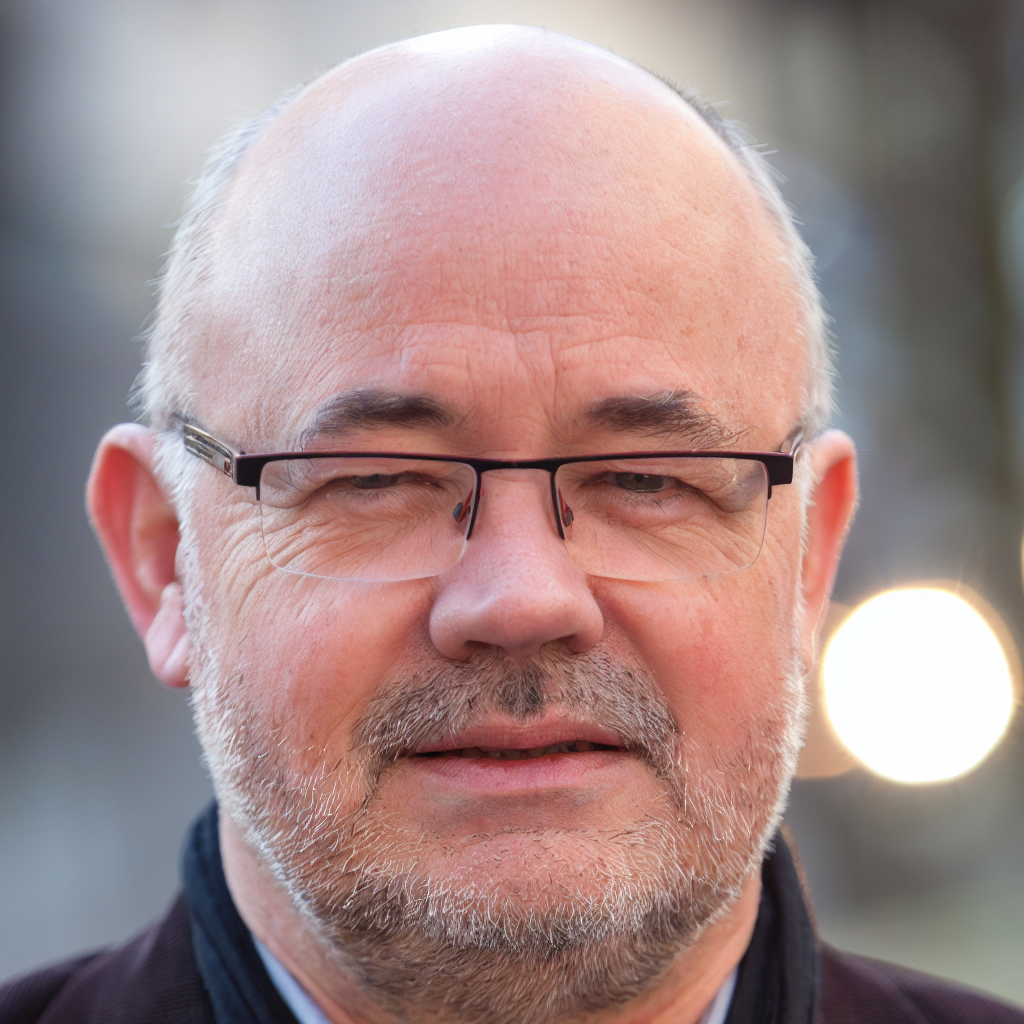

In [11]:
# Plot the Decoded Image
Image.fromarray(decoded_uint8)

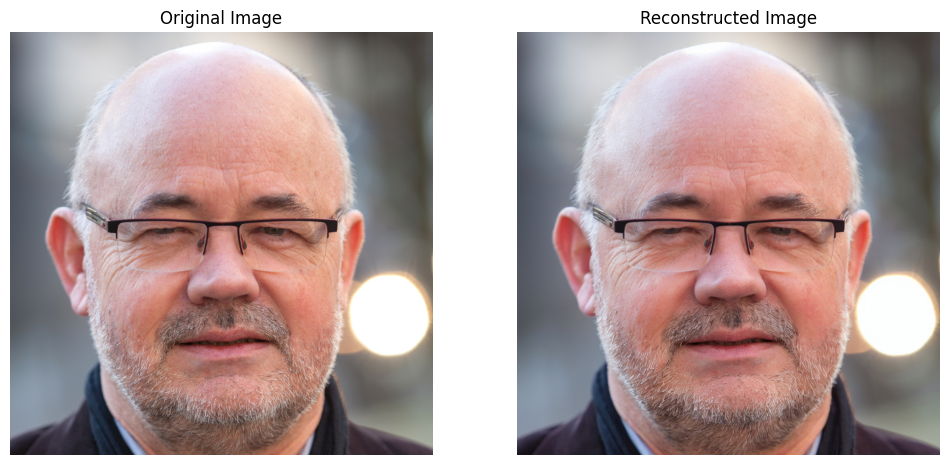

In [16]:
import matplotlib.pyplot as plt

# Get the original image from the dataset
original_image = im['image']

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off') # Hide axes ticks

# Display the decoded image
axes[1].imshow(decoded_uint8)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off') # Hide axes ticks

plt.show()

Shape of Original Image Numpy: (1024, 1024, 3), dtype: float32
Shape of Decoded Unit 8 Image Numpy: (1024, 1024, 3), dtype: uint8
Shape of Decoded Image Numpy: (1024, 1024, 3), dtype: float32
Minimum difference: 0.0
Maximum difference: 1.5843138694763184


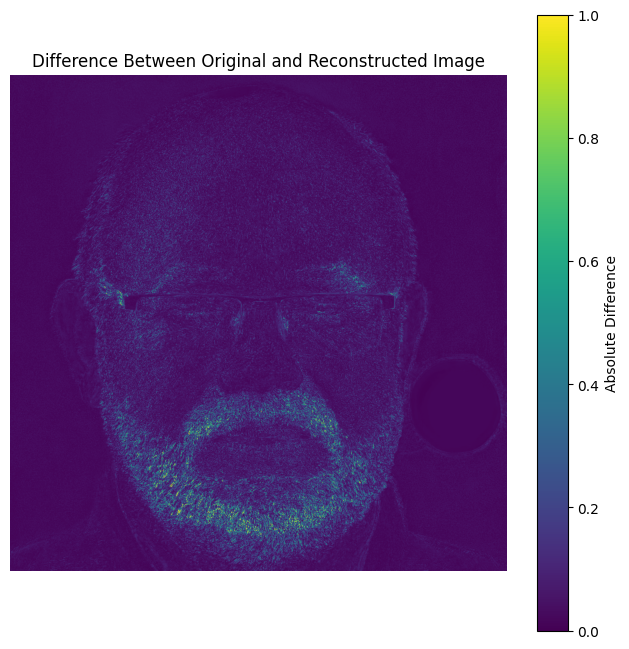

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

# Ensure original_image is a PIL Image
original_image_pil = im['image']

# Preprocess the original image to a tensor and convert to numpy for comparison
# We need to ensure it's in the same [0, 1] range and (H, W, C) format as image_numpy
preprocess_for_diff = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(), # Converts to [0, 1] range and (C, H, W)
])
original_image_tensor = preprocess_for_diff(original_image_pil)
original_image_numpy = original_image_tensor.permute(1, 2, 0).numpy()

# Calculate the absolute difference between the original and reconstructed images
# image_numpy is already in [0, 1] range and (H, W, C) format
print(f'Shape of Original Image Numpy: {original_image_numpy.shape}, dtype: {original_image_numpy.dtype}')
print(f'Shape of Decoded Unit 8 Image Numpy: {decoded_uint8.shape}, dtype: {decoded_uint8.dtype}')
print(f'Shape of Decoded Image Numpy: {decoded_numpy.shape}, dtype: {decoded_numpy.dtype}')
decoded_float = decoded_uint8.astype(np.float32) / 255.0
difference_image = np.abs(original_image_numpy - decoded_float).sum(axis=2)

print(f"Minimum difference: {difference_image.min()}")
print(f"Maximum difference: {difference_image.max()}")

# Display the difference image with adjusted colormap and value range
plt.figure(figsize=(8, 8))
plt.imshow(difference_image,vmax=1.)
plt.title('Difference Between Original and Reconstructed Image')
plt.axis('off')
plt.colorbar(label='Absolute Difference')
plt.show()

# Takeaway from using Stable Diffusion


The Results don't look that different but when you take the difference it because visual that the Stable Diffusion Model is worse. However I'm not sure we are seeing the same level of distortion as seen in the Silo Paper so maybe that's the next step